In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, SUBJECT_IDS

SAVE_ROOT = '../../' + SAVE_ROOT
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます

In [2]:

iou_q = 0.5
saliency_TR_q = 0.7

# testデータにおける, gaze_shiftとsaliency_shiftの共起回数や、それぞれの発生回数
behavior_path = os.path.join(SAVE_ROOT, 'behavior','behaviors20251029.csv')
behavior_df = pd.read_csv(behavior_path)
target_df = behavior_df.query(f'iou_q=={iou_q} and saliency_TR_q=={saliency_TR_q}')

total = np.array([int(i) for i in target_df['total'].item().replace('[','').replace(']','').replace(',', '').split(' ')])

sal = np.array([int(i) for i in target_df['sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
not_sal = np.array([int(i) for i in target_df['not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')]) #
eye = np.array([int(i) for i in target_df['eye'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_sal = np.array([int(i) for i in target_df['joint_eye_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_not_sal = np.array([int(i) for i in target_df['joint_eye_not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
prob_eye = eye/total
prob_inv_eye = joint_eye_sal/sal
prob_vol_eye = joint_eye_not_sal/not_sal
prob_sal = sal/total

print('Probability of Gaze Shift:', np.array(prob_eye))
print('Probability of Saliency Shift:', np.array(prob_sal))
print('Probability of Gaze Shift with Saliency Shift:', np.array(prob_inv_eye))
print('Probability of Gaze Shift without Saliency Shift:', np.array(prob_vol_eye))

prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)

print(prob_voluntary)
print(prob_involuntary)

Probability of Gaze Shift: [0.5031211  0.49299363 0.50636132 0.47399703 0.46134663 0.41304348
 0.47588832 0.43246592 0.46787709 0.52970297 0.51823899 0.4487021 ]
Probability of Saliency Shift: [0.34082397 0.34904459 0.34605598 0.32986627 0.34413965 0.342711
 0.34390863 0.34076828 0.33379888 0.34158416 0.34465409 0.33868974]
Probability of Gaze Shift with Saliency Shift: [0.56043956 0.54379562 0.50735294 0.51351351 0.47101449 0.45522388
 0.53874539 0.41818182 0.46443515 0.5942029  0.56569343 0.52189781]
Probability of Gaze Shift without Saliency Shift: [0.36971831 0.37142857 0.40659341 0.3976378  0.36140351 0.37090909
 0.35740072 0.41034483 0.37262357 0.45296167 0.40072202 0.29655172]
[0.36971831 0.37142857 0.40659341 0.3976378  0.36140351 0.37090909
 0.35740072 0.41034483 0.37262357 0.45296167 0.40072202 0.29655172]
[0.56043956 0.54379562 0.50735294 0.51351351 0.47101449 0.45522388
 0.53874539 0.41818182 0.46443515 0.5942029  0.56569343 0.52189781]


In [3]:
# FC (per-region delay = 各regionが初めて有意になった時刻)
#   37:R-SPL (td2 / 4s), 18:L-ACC/MPFC (td-1 / -2s), 35:R-LTL (td0 / 0s), 6:L-PCL/MC (td1 / 2s)
fc37 = np.load('fc-src36-tgt37-sd-1-td2-iq0.5-sq0.7-nbo.npy')
fc18 = np.load('fc-src36-tgt18-sd-1-td-1-iq0.5-sq0.7-nbo.npy')
fc35 = np.load('fc-src36-tgt35-sd-1-td0-iq0.5-sq0.7-nbo.npy')
fc6  = np.load('fc-src36-tgt6-sd-1-td1-iq0.5-sq0.7-nbo.npy')

In [4]:
# regression
def regression(x, y):
    reg = LinearRegression().fit(x, y)
    return reg.coef_[0], reg.intercept_[0]

/home/kazu/shared_response/figures/fig5/FC_vs_prob_eye_voluntary.pdf


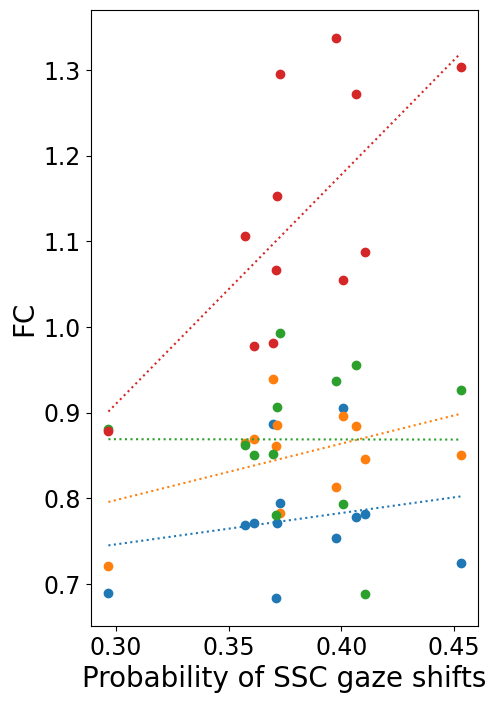

In [5]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_voluntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc6, label='L-PCL/MC')
a, b = regression(prob_voluntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc35, label='R-LTL')
a, b = regression(prob_voluntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc37, label='R-SPL')
a, b = regression(prob_voluntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.xlabel('Probability of SSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5', 'FC_vs_prob_eye_voluntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

/home/kazu/shared_response/figures/fig5/FC_vs_prob_eye_involuntary.pdf


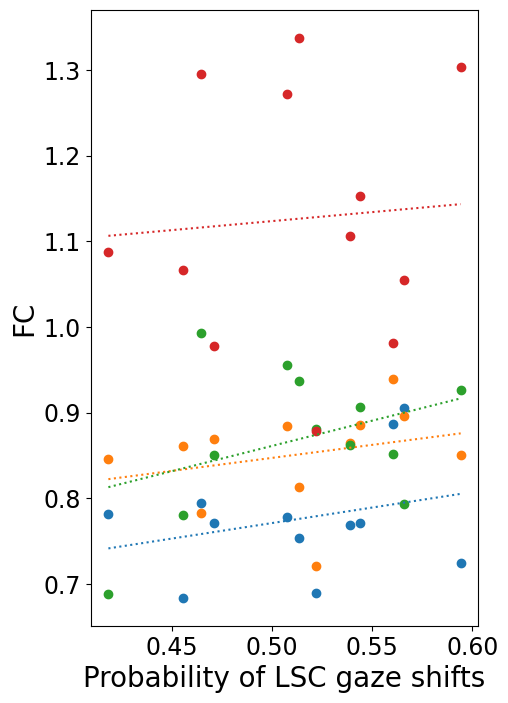

In [6]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_involuntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc6, label='L-PCL/MC')
a, b = regression(prob_involuntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc35, label='R-LTL')
a, b = regression(prob_involuntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc37, label='R-SPL')
a, b = regression(prob_involuntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5', 'FC_vs_prob_eye_involuntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, SUBJECT_IDS

SAVE_ROOT = '../../' + SAVE_ROOT
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます

/home/kazu/shared_response/figures/fig5_small/FC_vs_prob_eye_voluntary.pdf
/home/kazu/shared_response/figures/fig5_small/FC_vs_prob_eye_involuntary.pdf


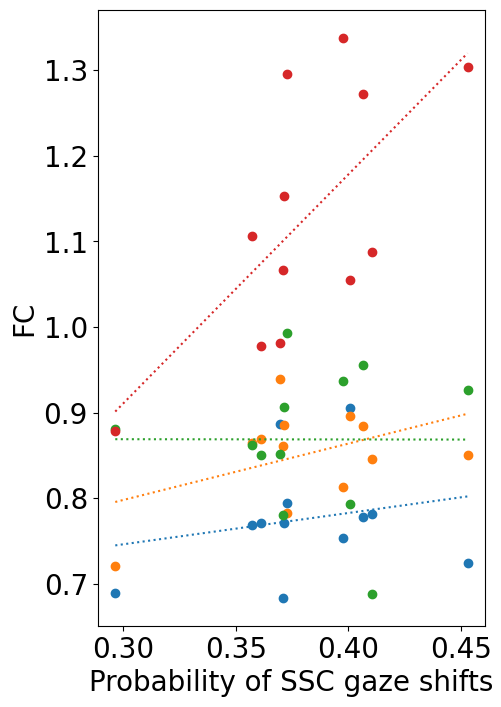

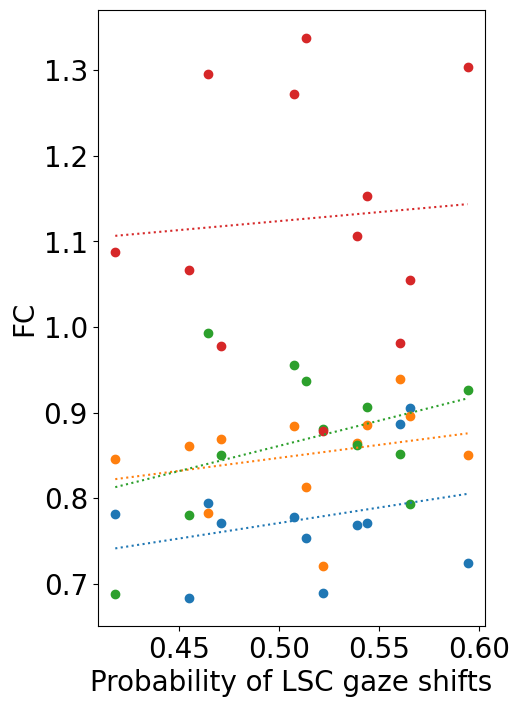

In [8]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_voluntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc6, label='L-PCL/MC')
a, b = regression(prob_voluntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc35, label='R-LTL')
a, b = regression(prob_voluntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc37, label='R-SPL')
a, b = regression(prob_voluntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.xlabel('Probability of SSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5_small', 'FC_vs_prob_eye_voluntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)

print(savepath)
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_involuntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc6, label='L-PCL/MC')
a, b = regression(prob_involuntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc35, label='R-LTL')
a, b = regression(prob_involuntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc37, label='R-SPL')
a, b = regression(prob_involuntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5_small', 'FC_vs_prob_eye_involuntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

# Leave one subject out cross-validation

In [9]:
prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)

fc37 = np.load('fc-src36-tgt37-sd-1-td2-iq0.5-sq0.7-nbo.npy')
fc18 = np.load('fc-src36-tgt18-sd-1-td-1-iq0.5-sq0.7-nbo.npy')
fc35 = np.load('fc-src36-tgt35-sd-1-td0-iq0.5-sq0.7-nbo.npy')
fc6  = np.load('fc-src36-tgt6-sd-1-td1-iq0.5-sq0.7-nbo.npy')


num_subjects = len(prob_voluntary)
subject_ids = np.arange(num_subjects)

voluntary_preds37 = []
voluntary_preds18 = []
voluntary_preds35 = []
voluntary_preds6 = []
for s in range(num_subjects):
    # fc37
    x = np.delete(fc37, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc37[s] + b
    voluntary_preds37.append(pred)
    # fc18
    x = np.delete(fc18, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc18[s] + b
    voluntary_preds18.append(pred)
    # fc35
    x = np.delete(fc35, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc35[s] + b
    voluntary_preds35.append(pred)
    # fc6
    x = np.delete(fc6, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc6[s] + b
    voluntary_preds6.append(pred)

involuntary_preds37 = []
involuntary_preds18 = []
involuntary_preds35 = []
involuntary_preds6 = []
for s in range(num_subjects):
    # fc37
    x = np.delete(fc37, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc37[s] + b
    involuntary_preds37.append(pred)
    # fc18
    x = np.delete(fc18, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc18[s] + b
    involuntary_preds18.append(pred)
    # fc35
    x = np.delete(fc35, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc35[s] + b
    involuntary_preds35.append(pred)
    # fc6
    x = np.delete(fc6, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc6[s] + b
    involuntary_preds6.append(pred)

voluntary_preds37 = np.concatenate(voluntary_preds37)
voluntary_preds18 = np.concatenate(voluntary_preds18)
voluntary_preds35 = np.concatenate(voluntary_preds35)
voluntary_preds6 = np.concatenate(voluntary_preds6)
involuntary_preds37 = np.concatenate(involuntary_preds37)
involuntary_preds18 = np.concatenate(involuntary_preds18)
involuntary_preds35 = np.concatenate(involuntary_preds35)
involuntary_preds6 = np.concatenate(involuntary_preds6)

print(voluntary_preds37)

[0.35236284 0.38673441 0.40609993 0.42503661 0.35319936 0.37024579
 0.37909609 0.37036051 0.41990086 0.40051563 0.36442617 0.35805946]


In [10]:
mae_voluntary37 = np.mean(np.abs(prob_voluntary - voluntary_preds37))
mae_voluntary18 = np.mean(np.abs(prob_voluntary - voluntary_preds18))
mae_voluntary35 = np.mean(np.abs(prob_voluntary - voluntary_preds35))
mae_voluntary6 = np.mean(np.abs(prob_voluntary - voluntary_preds6))

mae_involuntary37 = np.mean(np.abs(prob_involuntary - involuntary_preds37))
mae_involuntary18 = np.mean(np.abs(prob_involuntary - involuntary_preds18))
mae_involuntary35 = np.mean(np.abs(prob_involuntary - involuntary_preds35))
mae_involuntary6 = np.mean(np.abs(prob_involuntary - involuntary_preds6))

print('Voluntary Gaze Shift Prediction MAE:')
print('R-Superior Parietal lobule:', mae_voluntary37)
print('L-Anterior Cingulate and Medial Prefrontal cortex:', mae_voluntary18)
print('R-Lateral Temporal lobe:', mae_voluntary35)
print('L-Paracentral lobular and Mid Cingulate:', mae_voluntary6)
print('Involuntary Gaze Shift Prediction MAE:')
print('R-Superior Parietal lobule:', mae_involuntary37)
print('L-Anterior Cingulate and Medial Prefrontal cortex:', mae_involuntary18)
print('R-Lateral Temporal lobe:', mae_involuntary35)
print('L-Paracentral lobular and Mid Cingulate:', mae_involuntary6)

Voluntary Gaze Shift Prediction MAE:
R-Superior Parietal lobule: 0.0273856397977065
L-Anterior Cingulate and Medial Prefrontal cortex: 0.031727948611631945
R-Lateral Temporal lobe: 0.03334364834881518
L-Paracentral lobular and Mid Cingulate: 0.03631374220543861
Involuntary Gaze Shift Prediction MAE:
R-Superior Parietal lobule: 0.05006667583812069
L-Anterior Cingulate and Medial Prefrontal cortex: 0.046365397991922096
R-Lateral Temporal lobe: 0.052262776728335965
L-Paracentral lobular and Mid Cingulate: 0.050323573545208146


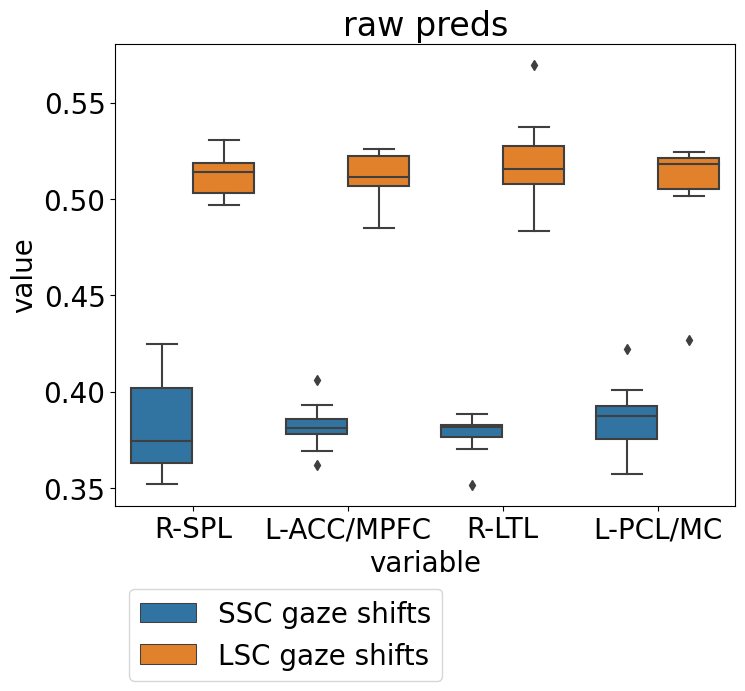

/home/kazu/shared_response/figures/sup_fig7/abserror_prob.pdf
R-SPL - t-statistic: -2.56002175460251, p-value: 0.026517579805476487
L-ACC/MPFC - t-statistic: -1.4057043819041741, p-value: 0.18742319500056687
R-LTL - t-statistic: -1.4827451197754409, p-value: 0.16621604699002548
L-PCL/MC - t-statistic: -1.7300687007002773, p-value: 0.11153723431298426


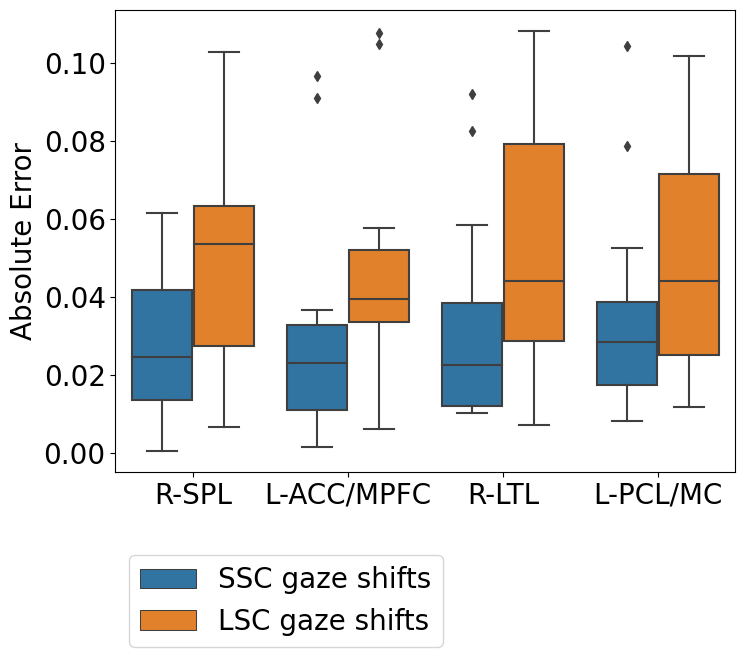

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plot_df = {
    'R-SPL': np.concatenate([voluntary_preds37, involuntary_preds37]),
    'L-ACC/MPFC': np.concatenate([voluntary_preds18, involuntary_preds18]),
    'R-LTL': np.concatenate([voluntary_preds35, involuntary_preds35]),
    'L-PCL/MC': np.concatenate([voluntary_preds6, involuntary_preds6]),
    'Type': ['SSC gaze shifts']*len(voluntary_preds37) + ['LSC gaze shifts']*len(involuntary_preds37)
}

df = pd.DataFrame(plot_df)

df.to_csv('fc6_loocv_preds20251029.csv', index=False)
# long形式に変換
df_melted = df.melt(id_vars="Type", var_name="variable", value_name="value")

# seabornで描画
plt.figure(figsize=(8,6))
sns.boxplot(x="variable", y="value", hue="Type", data=df_melted)
plt.title("raw preds")
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
plt.show()


plot_df = {
    'R-SPL': np.concatenate([voluntary_preds37, involuntary_preds37]),
    'L-ACC/MPFC': np.concatenate([voluntary_preds18, involuntary_preds18]),
    'R-LTL': np.concatenate([voluntary_preds35, involuntary_preds35]),
    'L-PCL/MC': np.concatenate([voluntary_preds6, involuntary_preds6]),
    'true_value': np.concatenate([prob_voluntary, prob_involuntary]),
    'Type': ['SSC gaze shifts']*len(voluntary_preds37) + ['LSC gaze shifts']*len(involuntary_preds37)
}


df = pd.DataFrame(plot_df)

df['R-SPL'] = df.apply(lambda row: np.abs(row['true_value'] - row['R-SPL']), axis=1)
df['L-ACC/MPFC'] = df.apply(lambda row: np.abs(row['true_value'] - row['L-ACC/MPFC']), axis=1)
df['R-LTL'] = df.apply(lambda row: np.abs(row['true_value'] - row['R-LTL']), axis=1)
df['L-PCL/MC'] = df.apply(lambda row: np.abs(row['true_value'] - row['L-PCL/MC']), axis=1)
df = df.drop(columns=['true_value'])
df.to_csv('fc6_loocv_AbsError_20251029.csv', index=False)
# long形式に変換
df_melted = df.melt(id_vars="Type", var_name="variable", value_name="value")

# seabornで描画
df_melted['Absolute Error'] = df_melted['value']

plt.figure(figsize=(8,6))
ax = sns.boxplot(x="variable", y="Absolute Error", hue="Type", data=df_melted)
ax.set_xlabel(None)
# plt.title("Absolute Error")
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
# plt.show()

savepath =os.path.join('/home/kazu/shared_response/figures', 'sup_fig7', 'abserror_prob.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)



# t検定

## R-SPL
from scipy.stats import ttest_rel
for var in ["R-SPL", "L-ACC/MPFC", "R-LTL", "L-PCL/MC"]:
    a_vals = df.loc[df["Type"] == "SSC gaze shifts", var].reset_index(drop=True)
    b_vals = df.loc[df["Type"] == "LSC gaze shifts", var].reset_index(drop=True)
    t_stat, p_val = ttest_rel(a_vals, b_vals)
    print(f"{var} - t-statistic: {t_stat}, p-value: {p_val}")

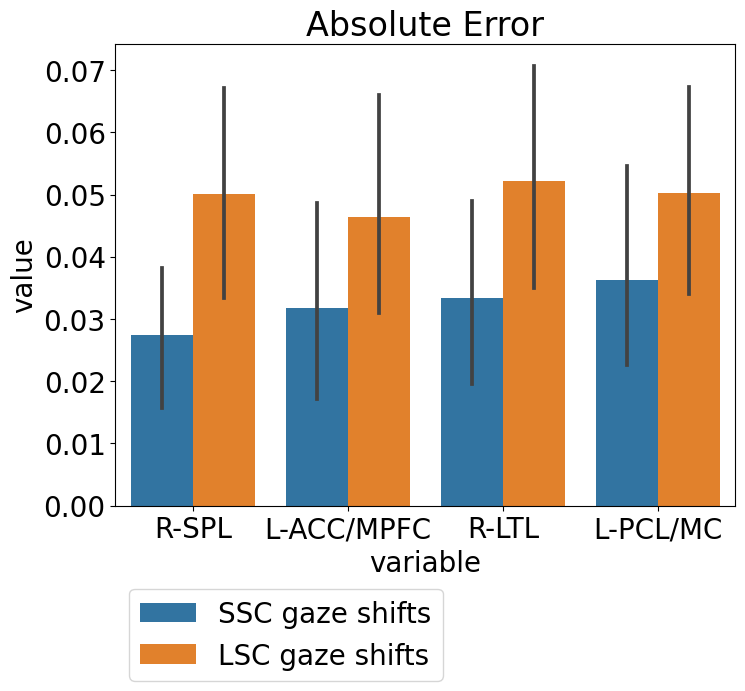

In [14]:
# seabornで描画
plt.figure(figsize=(8,6))
sns.barplot(x="variable", y="value", hue="Type", data=df_melted)
plt.title("Absolute Error")
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
plt.show()

In [26]:
df_melted

,Type,variable,value
0,Small saliency change,R-SPL,0.017355
1,Small saliency change,R-SPL,0.015306
2,Small saliency change,R-SPL,0.000493
3,Small saliency change,R-SPL,0.027399
4,Small saliency change,R-SPL,0.008204
...,...,...,...
91,Large saliency change,L-PCL/MC,0.100851
92,Large saliency change,L-PCL/MC,0.045853
93,Large saliency change,L-PCL/MC,0.087220
94,Large saliency change,L-PCL/MC,0.050477


In [28]:
df


,R-SPL,L-ACC/MPFC,R-LTL,L-PCL/MC,Type
0,0.017355,0.010155,0.011772,0.043229,Small saliency change
1,0.015306,0.046008,0.010391,0.033720,Small saliency change
2,0.000493,0.008786,0.028936,0.021599,Small saliency change
3,0.027399,0.039038,0.018360,0.039282,Small saliency change
4,0.008204,0.018517,0.022757,0.025079,Small saliency change
5,0.000663,0.027488,0.010515,0.022186,Small saliency change
6,0.021695,0.018384,0.029358,0.021348,Small saliency change
7,0.039984,0.036939,0.048863,0.036766,Small saliency change
8,0.047277,0.045091,0.011368,0.004709,Small saliency change
9,0.052446,0.062936,0.099864,0.076631,Small saliency change


In [33]:
small_saliency_df

,Type,variable,value
0,Small saliency change,R-SPL,0.017355
1,Small saliency change,R-SPL,0.015306
2,Small saliency change,R-SPL,0.000493
3,Small saliency change,R-SPL,0.027399
4,Small saliency change,R-SPL,0.008204
5,Small saliency change,R-SPL,0.000663
6,Small saliency change,R-SPL,0.021695
7,Small saliency change,R-SPL,0.039984
8,Small saliency change,R-SPL,0.047277
9,Small saliency change,R-SPL,0.052446


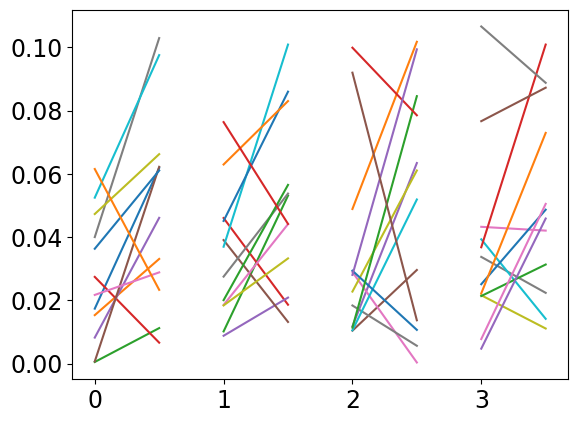

In [34]:
small_saliency_df = df_melted[df_melted['Type'] == 'Small saliency change']
large_saliency_df = df_melted[df_melted['Type'] == 'Large saliency change']

for v, var in enumerate(["R-SPL", "L-ACC/MPFC", "R-LTL", "L-PCL/MC"]):
    s_vals = small_saliency_df[small_saliency_df['variable'] == var]['value'].values
    l_vals = large_saliency_df[large_saliency_df['variable'] == var]['value'].values
    for s, l in zip(s_vals, l_vals):
        plt.plot([v, v+0.5], [s, l], label=var)

In [24]:
prob_voluntary
voluntary_preds37

array([0.35236284, 0.38673442, 0.40609993, 0.42503661, 0.35319935,
       0.37024579, 0.37909609, 0.37036051, 0.41990086, 0.40051563,
       0.36442617, 0.35805946])

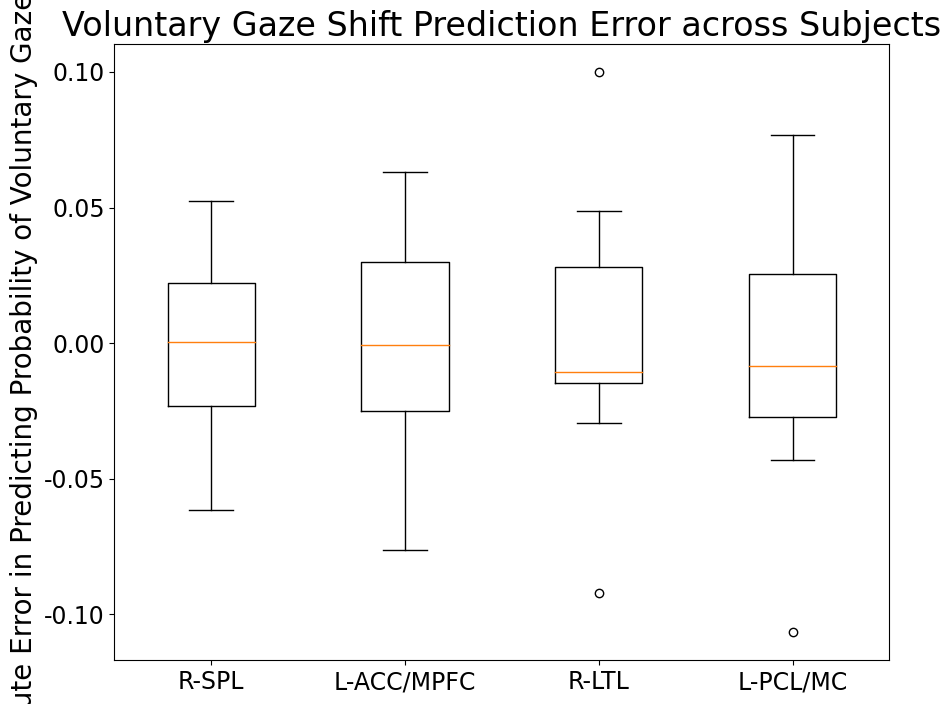

In [25]:
fig = plt.figure(figsize=(10,8))
plt.boxplot([(prob_voluntary - np.array(voluntary_preds37)),
             (prob_voluntary - np.array(voluntary_preds18)),
             (prob_voluntary - np.array(voluntary_preds35)),
             (prob_voluntary - np.array(voluntary_preds6))],
            labels=['R-SPL', 'L-ACC/MPFC',
                    'R-LTL', 'L-PCL/MC'])
plt.ylabel('Absolute Error in Predicting Probability of Voluntary Gaze Shift')
plt.title('Voluntary Gaze Shift Prediction Error across Subjects')
plt.show()